# Taller 01 · Parte 1 — Comparación de modelos

**Objetivo:** desarrollar criterio para elegir el modelo correcto para un problema dado. Ejecutamos **el mismo prompt** sobre **tres modelos** de la tabla semestral y medimos, con números y no con impresiones:

1. **Calidad**: exactitud sobre tus 10 casos verificables.
2. **Latencia** en segundos (abajo declaramos exactamente qué se mide).
3. **Costo en USD**: tokens de entrada × precio de entrada + tokens de salida × precio de salida, con el precio **leído de la tabla** y la **fecha de verificación** de esa fila.
4. **Observaciones cualitativas**: ¿respeta el formato?, ¿es verboso?, ¿inventa?

**Las tres ranuras** (sin clave de Anthropic, así lo propone el enunciado):

| Ranura | Fila de la tabla | Dónde corre |
|---|---|---|
| Propietario grande | openai_razonamiento | API de OpenAI |
| Propietario económico | propietario_economico | API de OpenAI |
| Open-weight local | open_weight_pequeno (qwen3:1.7b) | Ollama  |

Cada llamada queda registrada en resultados/resultados.csv (una fila por llamada); **las tablas de este cuaderno se derivan de ese archivo**.

## 0. Preparación y confirmación de precios
cargar_env(). Luego mostramos los precios tal como salen del archivo fuentes/modelos/modelos-2026-1.json, con la fecha de verificación de **cada fila**: esa tabla es la confirmación de que los precios no vienen de la memoria.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from taller_01_miguel_alvarez import tallerlib as tl

print("Variables leídas de .env (solo nombres):", tl.cargar_env())
print("OPENAI_API_KEY utilizable:", tl.hay_clave("OPENAI_API_KEY"))
tl.DIR_FIGURAS.mkdir(exist_ok=True)
tl.DIR_RESULTADOS.mkdir(exist_ok=True)

casos = tl.cargar_casos("principal")
print(f"Casos principales: {len(casos)}")

filas = []
for mid, rol in tl.RANURAS_PARTE1.items():
    f = tl.fila_modelo(mid)
    filas.append({"ranura": rol, "id": mid, "modelo": f["modelo"],
                  "USD/M entrada": f["precio_entrada_usd_por_millon"],
                  "USD/M salida": f["precio_salida_usd_por_millon"],
                  "precio verificado": f["verificado"] or "- (cero real, local)"})
precios = pd.DataFrame(filas)
print()
print("Precios leídos de:", tl.RUTA_TABLA.relative_to(tl.RAIZ))
print(precios.to_string(index=False))

Variables leídas de .env (solo nombres): []
OPENAI_API_KEY utilizable: True
Casos principales: 10

Precios leídos de: fuentes/modelos/modelos-2026-1.json
                                             ranura                    id       modelo  USD/M entrada  USD/M salida    precio verificado
propietario grande (fila de razonamiento de OpenAI)   openai_razonamiento gpt-5.6-luna           0.20           1.2           2026-09-18
              propietario economico para produccion propietario_economico  gpt-4o-mini           0.15           0.6           2026-08-26
                         open-weight local (Ollama)   open_weight_pequeno   qwen3:1.7b           0.00           0.0 - (cero real, local)


## 1. Condiciones del experimento
Para que la comparación sea justa, los tres reciben **el mismo prompt** (la instrucción exacta de las Partes 1 a 4 más el problema). Lo que cambia son los diales que cada fila admite:

- propietario_economico: temperature = 0, tope de 100 tokens de salida.
- open_weight_pequeno: temperature = 0, think = False (sin razonamiento), tope de 100 tokens.
- openai_razonamiento: **no admite temperature** (se comprueba en la Parte 2.a), así que va con el esfuerzo de razonamiento por defecto (medium) y un tope de seguridad de 16 000 tokens de salida.

Una corrida por caso. Secuencial (una llamada a la vez) para que la latencia sea limpia.

In [2]:
print("Prompt exacto (ejemplo con el primer caso):")
print(tl.construir_prompt(casos[0]["enunciado"]))
print()
for mid, p in tl.PARAMS_PARTE1.items():
    print(f"{mid:<24} {p}")

Prompt exacto (ejemplo con el primer caso):
Solve the arithmetic problem. Reply with the final integer only: no thousands separators, no decimals, no explanation.

Problem: Calculate 901 + 369 + 7123
Answer:

openai_razonamiento      {'max_output_tokens': 16000}
propietario_economico    {'temperature': 0, 'max_output_tokens': 100}
open_weight_pequeno      {'temperature': 0, 'think': False, 'num_predict': 100}


## 2. Estimación de costo ANTES de lanzar
Se estima antes de gastar, con los precios de la fila y su fecha. Supuestos declarados: unos 4 caracteres por token en la entrada; salida de ~10 tokens para los dos modelos que responden directo; y **3 000 tokens de salida total** para la fila de razonamiento (el número que el enunciado usa para el esfuerzo medio: es un supuesto, no una medición; abajo lo comparamos con lo medido).

In [3]:
prompts = {c["id"]: tl.construir_prompt(c["enunciado"]) for c in casos}
tok_in = round(np.mean([len(p) / 4 for p in prompts.values()]))
SUPUESTO_SALIDA = {"openai_razonamiento": 3000, "propietario_economico": 10, "open_weight_pequeno": 10}

est = []
for mid in tl.MODELOS_PARTE1:
    n = len(casos)
    usd = tl.costo_usd(mid, tok_in * n, SUPUESTO_SALIDA[mid] * n)
    est.append({"id": mid, "llamadas": n, "tokens_entrada_supuestos": tok_in, "tokens_salida_supuestos": SUPUESTO_SALIDA[mid], "USD_estimado": round(usd, 5)})
estimacion = pd.DataFrame(est)
print(estimacion.to_string(index=False))
print(f"\nEstimación total de la Parte 1: {estimacion.USD_estimado.sum():.4f} USD (presupuesto orientativo del taller para esta parte: 0.21 USD)")

                   id  llamadas  tokens_entrada_supuestos  tokens_salida_supuestos  USD_estimado
  openai_razonamiento        10                        40                     3000       0.03608
propietario_economico        10                        40                       10       0.00012
  open_weight_pequeno        10                        40                       10       0.00000

Estimación total de la Parte 1: 0.0362 USD (presupuesto orientativo del taller para esta parte: 0.21 USD)


## 3. Calentamiento y piloto (1 caso por modelo)
Antes de lanzar las 30 llamadas, una llamada por modelo con el primer caso. Sirve para: (a) cargar el modelo en Ollama (la primera llamada incluye la carga en memoria, así que **no cuenta** para la latencia), (b) comprobar que la clave, el nombre del modelo y el formato de la respuesta funcionan, y (c) que si algo falla, falle barato. Estas llamadas se registran como parte `1w` y **se excluyen** de las tablas.

In [4]:
tl.reemplazar_partes({"1", "1w"})   # re-ejecutar no duplica filas

piloto = casos[0]
errores_piloto = []
for mid in tl.MODELOS_PARTE1:
    fila = tl.llamar(mid, prompts[piloto["id"]], tl.PARAMS_PARTE1[mid], parte="1w", caso=piloto["id"],
                     variante="calentamiento", esperado=piloto["respuesta_esperada"])
    print(f"{mid:<24} salida={fila['salida'].strip()[:40]!r:<44} acierto={fila['acierto']}  {fila['latencia_s']}s  error={fila['error'][:200] or '-'}")
    if fila["error"]:
        errores_piloto.append(mid)

if errores_piloto:
    raise RuntimeError(f"El piloto falló en {errores_piloto}. Arregla eso antes de seguir (no se ha gastado casi nada).")
print("\nPiloto sin errores: se puede lanzar la corrida completa.")

openai_razonamiento      salida='8393'                                       acierto=1  2.0372s  error=-
propietario_economico    salida='8193'                                       acierto=0  0.9685s  error=-
open_weight_pequeno      salida='901 + 369 + 7123 = 8493'                    acierto=0  2.1448s  error=-

Piloto sin errores: se puede lanzar la corrida completa.


## 4. Corrida completa: 3 modelos × 10 casos = 30 llamadas
`correr_lote` tiene un **freno de costo** (`max_usd`): si el gasto acumulado del lote lo supera, se detiene y avisa.

In [5]:
MAX_USD = 0.50
tareas = [dict(modelo_id=mid, prompt=prompts[c["id"]], params=tl.PARAMS_PARTE1[mid], parte="1",
               caso=c["id"], variante=c["nivel"], corrida=0, esperado=c["respuesta_esperada"])
          for mid in tl.MODELOS_PARTE1 for c in casos]
resultado_lote = tl.correr_lote(tareas, hilos=1, max_usd=MAX_USD)

Tareas: 30 | ya hechas (omitidas): 0 | por correr: 30
[1/30] openai_razonamiento      F1   ok    1.0282s  4.7e-05 USD  -> '8393'
[2/30] openai_razonamiento      F2   ok    1.2772s  4.34e-05 USD  -> '311'
[3/30] openai_razonamiento      M1   ok    1.3745s  3.66e-05 USD  -> '731'
[4/30] openai_razonamiento      M2   ok    1.4347s  3.9e-05 USD  -> '2160'
[5/30] openai_razonamiento      D1   ok    1.1935s  5.22e-05 USD  -> '76626'
[6/30] openai_razonamiento      D2   ok    1.5078s  5.46e-05 USD  -> '63344'
[7/30] openai_razonamiento      D3   ok    1.7233s  4.86e-05 USD  -> '172568'
[8/30] openai_razonamiento      X1   ok    1.2996s  6.44e-05 USD  -> '5021952'
[9/30] openai_razonamiento      X2   ok    1.7374s  7.16e-05 USD  -> '3863735'
[10/30] openai_razonamiento      P1   ok    1.4377s  4.52e-05 USD  -> '419'
[11/30] propietario_economico    F1   x     1.3345s  8.4e-06 USD  -> '8193'
[12/30] propietario_economico    F2   ok    0.8206s  7.8e-06 USD  -> '311'
[13/30] propietario_economico

## 5. Tabla comparativa
Todo se calcula desde las filas crudas de resultados.csv (parte 1). Columnas: exactitud, **formato correcto** (la salida es *solo* un entero, como pedía la instrucción), latencia media y mediana, tokens medios, costo de los 10 casos, costo extrapolado a **1 000 problemas** (útil para decidir en producción) y la **fecha del precio**.

In [6]:
df = pd.DataFrame([f for f in tl.leer_filas() if f["parte"] == "1"])
for c in ["tokens_entrada", "tokens_salida", "tokens_razonamiento", "latencia_s", "costo_usd", "acierto", "prediccion", "esperado"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["formato_ok"] = df["salida"].map(tl.es_solo_entero).astype(int)

resumen = []
for mid in tl.MODELOS_PARTE1:
    d = df[df.modelo_id == mid]
    t = tl.fila_modelo(mid)
    resumen.append({
        "ranura": tl.RANURAS_PARTE1[mid], "id": mid, "modelo": t["modelo"],
        "exactitud": f"{int(d.acierto.sum())}/{len(d)}", "exactitud_%": round(100 * d.acierto.mean(), 1),
        "formato_ok_%": round(100 * d.formato_ok.mean(), 1),
        "latencia_media_s": round(d.latencia_s.mean(), 3), "latencia_mediana_s": round(d.latencia_s.median(), 3),
        "tokens_entrada_medio": round(d.tokens_entrada.mean(), 1), "tokens_salida_medio": round(d.tokens_salida.mean(), 1),
        "tokens_razonamiento_medio": round(d.tokens_razonamiento.mean(), 1),
        "costo_10_casos_USD": round(d.costo_usd.sum(), 6), "costo_por_1000_problemas_USD": round(d.costo_usd.mean() * 1000, 4),
        "USD/M_entrada": t["precio_entrada_usd_por_millon"], "USD/M_salida": t["precio_salida_usd_por_millon"],
        "precio_verificado": t["verificado"] or "- (cero real)",
        "llamadas_con_error": int((d.error != "").sum()),
    })
tabla_p1 = pd.DataFrame(resumen)
tabla_p1.to_csv(tl.RAIZ / "resultados" / "p1_tabla.csv", index=False)
print(tabla_p1.drop(columns=["ranura"]).T.to_string(header=False))

id                            openai_razonamiento  propietario_economico  open_weight_pequeno
modelo                               gpt-5.6-luna            gpt-4o-mini           qwen3:1.7b
exactitud                                   10/10                   3/10                 4/10
exactitud_%                                 100.0                   30.0                 40.0
formato_ok_%                                100.0                  100.0                 20.0
latencia_media_s                            1.401                  1.083                0.285
latencia_mediana_s                          1.405                  0.911                0.294
tokens_entrada_medio                         40.7                   41.7                 55.5
tokens_salida_medio                          35.1                    2.8                 21.8
tokens_razonamiento_medio                    27.2                    0.0                  0.0
costo_10_casos_USD                       0.000503           

### Dónde falla cada modelo
Para cada respuesta incorrecta: qué esperábamos, qué dijo y **qué tan lejos** estuvo (error relativo). Un modelo que falla por 1 % (cifras casi bien) se comporta distinto de uno que inventa un número de otro orden de magnitud.

In [7]:
mal = df[df.acierto == 0].copy()
mal["error_relativo_%"] = (100 * (mal.prediccion - mal.esperado).abs() / mal.esperado).round(4)
mal["orden_de_magnitud_ok"] = (mal.prediccion.abs().map(lambda x: len(str(int(abs(x)))) if pd.notna(x) else -1)
                               == mal.esperado.abs().map(lambda x: len(str(int(x)))))
errores = mal[["modelo_id", "caso", "variante", "esperado", "prediccion", "error_relativo_%", "orden_de_magnitud_ok", "salida"]]
errores.to_csv(tl.RAIZ / "resultados" / "p1_errores.csv", index=False)
print(errores.assign(salida=errores.salida.str.slice(0, 30)).to_string(index=False) if len(errores) else "Ninguna respuesta incorrecta.")

            modelo_id caso    variante  esperado  prediccion  error_relativo_%  orden_de_magnitud_ok                           salida
propietario_economico   F1       fácil      8393        8193            2.3829                  True                             8193
propietario_economico   D1     difícil     76626       76526            0.1305                  True                            76526
propietario_economico   D2     difícil     63344       63424            0.1263                  True                            63424
propietario_economico   D3     difícil    172568      172048            0.3013                  True                           172048
propietario_economico   X1 muy difícil   5021952      502752           89.9889                 False                           502752
propietario_economico   X2 muy difícil   3863735     3862035            0.0440                  True                          3862035
propietario_economico   P1   multipaso       419         429  

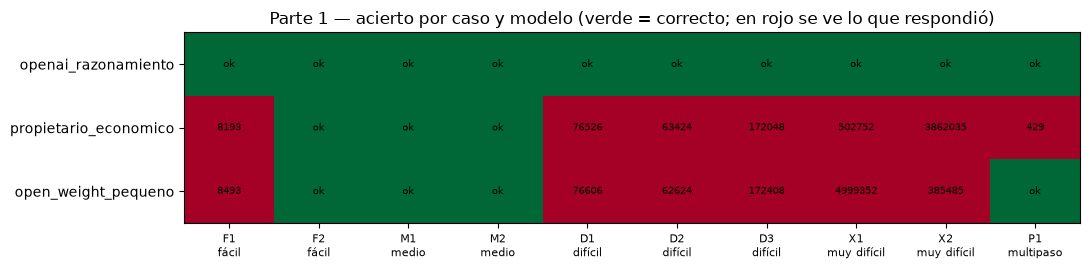

In [8]:
orden = [c["id"] for c in casos]
fig, ax = plt.subplots(figsize=(11, 2.8))
matriz = np.array([[df[(df.modelo_id == mid) & (df.caso == cid)].acierto.iloc[0] for cid in orden] for mid in tl.MODELOS_PARTE1], dtype=float)
ax.imshow(matriz, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(orden)))
ax.set_xticklabels([f"{c['id']}\n{c['nivel']}" for c in casos], fontsize=8)
ax.set_yticks(range(len(tl.MODELOS_PARTE1)))
ax.set_yticklabels(tl.MODELOS_PARTE1)
for i, mid in enumerate(tl.MODELOS_PARTE1):
    for j, cid in enumerate(orden):
        fila = df[(df.modelo_id == mid) & (df.caso == cid)].iloc[0]
        ax.text(j, i, "ok" if fila.acierto == 1 else ("vacío" if pd.isna(fila.prediccion) else f"{fila.prediccion:.0f}"),
                ha="center", va="center", fontsize=7)
ax.set_title("Parte 1 — acierto por caso y modelo (verde = correcto; en rojo se ve lo que respondió)")
fig.tight_layout()
fig.savefig(tl.DIR_FIGURAS / "p1_aciertos.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Qué se mide como «latencia» (declaración obligatoria)
**Latencia = tiempo de pared (time.perf_counter) de UNA petición completa, sin streaming, desde que se envía hasta que llega la respuesta entera.** 

- En las dos filas de OpenAI incluye red, cola del proveedor y generación; depende de la hora y la carga. El SDK reintenta hasta 2 veces ante errores transitorios (429/5xx), y ese tiempo cuenta.
- En Ollama incluye la generación en **tu** MacBook. La carga del modelo en memoria queda fuera porque la primera llamada (1w) la absorbe.
- **No** es tiempo hasta el primer token (eso exigiría streaming) y **no** es comparable en sentido estricto entre API y local: hardware y red distintos. Sirve para comparar el orden de magnitud y para decidir.
- Se reportan **media y mediana** de 10 llamadas por modelo: con tan pocas, la mediana resiste mejor un valor atípico.

## 7. Observaciones cualitativas
Salidas crudas que **no** respetan el formato pedido (solo un entero), y las respuestas erróneas ya vistas arriba. Con esto contestamos: ¿respeta el formato?, ¿es verboso?, ¿inventa números?

In [9]:
fuera = df[df.formato_ok == 0][["modelo_id", "caso", "tokens_salida", "salida"]].copy()
fuera["salida"] = fuera.salida.str.replace("\n", "\\n").str.slice(0, 90)
print(f"Salidas que NO son solo un entero: {len(fuera)} de {len(df)}")
print(fuera.to_string(index=False) if len(fuera) else "Todas las salidas respetan el formato.")

Salidas que NO son solo un entero: 8 de 30
          modelo_id caso  tokens_salida                                                  salida
open_weight_pequeno   F1             21                                 901 + 369 + 7123 = 8493
open_weight_pequeno   F2             31                     1010 - 243 - 456 = 1010 - 699 = 311
open_weight_pequeno   D1             15                                        774 × 99 = 76606
open_weight_pequeno   D2             25                      856 × 74 = 62,624\n\nAnswer: 62624
open_weight_pequeno   D3             30            583 × 296 = 172, 408\n\nFinal answer: 172408
open_weight_pequeno   X1             19                                    9984 × 503 = 4999352
open_weight_pequeno   X2             31           8345 × 463 = 385, 485\n\nFinal answer: 385485
open_weight_pequeno   P1             37 43% of 1000 is 430.  \n430 - 11 = 419.  \n\nAnswer: 419
